# 00 · Randomness and pseudo-random generators

Every simulation in this course starts from a stream of numbers that behave as if they were independent and
uniform on [0, 1). Computers produce them by deterministic recurrences - pseudo-random generators - and the
quality of everything downstream depends on how well the illusion holds. This notebook builds the classical
generators, shows a famous failure (IBM's RANDU, whose triples lie on 15 planes), tests generators
statistically, and ends with the practical rules for seeding and parallel streams in NumPy.

**What you will learn**
- explain how linear congruential generators work and when they reach full period
- recognise lattice structure and the RANDU defect
- apply and interpret statistical tests of uniformity and independence
- seed and spawn independent streams reproducibly

**Before you start:** basic probability (uniform distribution, independence), Python and NumPy  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import rng as rg, rngtests as rt
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Linear congruential generators

In [2]:
g = rg.LCG(5, 3, 16, seed=7)
print("x -> 5x + 3 mod 16 from 7:", g.integers(20).tolist())
print("period:", rg.LCG(5, 3, 16).period(), "| Hull-Dobell conditions:", rg.full_period_conditions(5, 3, 16))
print("x -> 4x + 3 mod 16:", rg.LCG(4, 3, 16, seed=7).integers(12).tolist(), "- stuck at a fixed point after one step")
pm = rg.LCG.park_miller(seed=1)
print("\nPark-Miller minimal standard, first values:", pm.integers(3).tolist())
pm = rg.LCG.park_miller(seed=1); pm.integers(9999)
print("x_10000 =", int(pm.integers(1)[0]), "(the published check value is 1043618065)")

x -> 5x + 3 mod 16 from 7: [6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7, 6, 1, 8, 11]
period: 16 | Hull-Dobell conditions: True
x -> 4x + 3 mod 16: [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15] - stuck at a fixed point after one step

Park-Miller minimal standard, first values: [16807, 282475249, 1622650073]
x_10000 = 1043618065 (the published check value is 1043618065)


A linear congruential generator x_{k+1} = (a x_k + c) mod m is a finite-state machine: it must cycle, and the
cycle length is at most m. The Hull-Dobell theorem says when the full period m is reached (c coprime to m,
a − 1 divisible by every prime factor of m, and by 4 if m is). The multiplicative Park-Miller generator
(c = 0, m = 2³¹ − 1 prime) cycles through all 2³¹ − 2 non-zero states because 16807 is a primitive root, and it
comes with a published check value - the way generator implementations are tested.

## RANDU and the lattice structure

9 u_k - 6 u_k+1 + u_k+2 takes only the integer values [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9] -> 15 planes
1-D and 2-D tests do not notice: chi-square p = 0.034, serial pairs p = 0.416


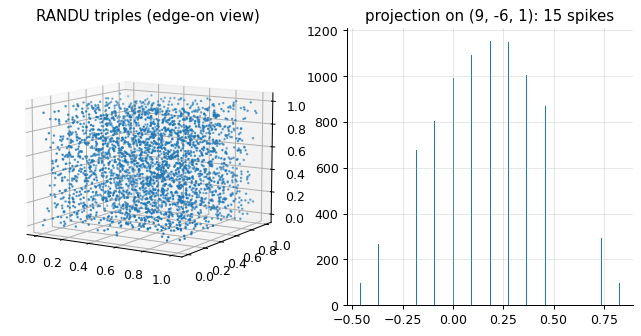

In [3]:
u = rg.LCG.randu(seed=1).random(30_000)
pl = rt.randu_planes(u)
print(f"9 u_k - 6 u_k+1 + u_k+2 takes only the integer values {pl['plane_values'].tolist()} -> {pl['n_planes']} planes")
print("1-D and 2-D tests do not notice:", f"chi-square p = {rt.chi_square_uniform(u)['p_value']:.3f}, serial pairs p = {rt.serial_test(u)['p_value']:.3f}")
t3 = u[: 3 * 10_000].reshape(-1, 3)
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d"); ax.scatter(*t3[:3000].T, s=1); ax.view_init(elev=10, azim=-58); ax.set_title("RANDU triples (edge-on view)")
ax = fig.add_subplot(1, 2, 2); proj = t3 @ np.array([9, -6, 1]) / np.sqrt(118); ax.hist(proj, bins=300); ax.set_title("projection on (9, -6, 1): 15 spikes"); plt.show()

RANDU (a = 65539 = 2¹⁶ + 3, m = 2³¹) was the standard generator on IBM mainframes in the 1960s and 70s. Because
a² = 6a − 9 (mod 2³¹), every triple satisfies x_{k+2} − 6x_{k+1} + 9x_k ≡ 0: the points (u_k, u_{k+1}, u_{k+2})
fill only 15 parallel planes of the unit cube, 1/√118 ≈ 0.09 apart. Every LCG has such a lattice (Marsaglia's
theorem); good multipliers make the planes many and close together, which the spectral test measures.

## The spectral test and statistical tests

In [4]:
for name, a, m in (("Park-Miller", 16807, 2**31 - 1), ("Park-Miller alternative 48271", 48271, 2**31 - 1), ("RANDU", 65539, 2**31), ("a = 3", 3, 2**31 - 1)):
    s2 = rt.spectral_test_2d(a, m)
    print(f"{name:<30}: 2-D lines {s2['line_spacing']:.2e} apart (best possible {1 / np.sqrt(2 / np.sqrt(3) * m):.2e}), figure of merit {s2['merit']:.3f}")
gens = {"PCG32": rg.PCG32(1, 1).random(50_000), "xorshift64*": rg.XorShift64Star(5).random(50_000), "Park-Miller": rg.LCG.park_miller(1).random(50_000),
        "RANDU": rg.LCG.randu(1).random(50_000), "LCG mod 16": rg.LCG(5, 3, 16).random(50_000)}
rows = []
for name, x in gens.items():
    rows.append((name, rt.chi_square_uniform(x)["p_value"], rt.serial_test(x)["p_value"], rt.runs_up_test(x)["p_value"], rt.gap_test(x)["p_value"], rt.autocorrelation_test(x)["p_value"]))
print(pd.DataFrame(rows, columns=["generator", "chi-square", "serial", "runs up", "gap", "lag-1 corr"]).to_string(index=False, float_format="%.3g"))

Park-Miller                   : 2-D lines 5.95e-05 apart (best possible 2.01e-05), figure of merit 0.338
Park-Miller alternative 48271 : 2-D lines 2.24e-05 apart (best possible 2.01e-05), figure of merit 0.896
RANDU                         : 2-D lines 2.16e-05 apart (best possible 2.01e-05), figure of merit 0.931
a = 3                         : 2-D lines 3.16e-01 apart (best possible 2.01e-05), figure of merit 0.000
  generator  chi-square  serial  runs up   gap  lag-1 corr
      PCG32       0.923    0.32    0.867 0.833        0.82
xorshift64*       0.959   0.526     0.39 0.486       0.122
Park-Miller        0.17   0.191     0.29 0.745       0.534
      RANDU       0.358   0.707    0.262 0.148       0.843
 LCG mod 16           0       0        0     0           0


Statistical tests can only find evidence *against* a generator: a p-value below a threshold flags a defect,
and a large one proves nothing (RANDU passes all five tests here - its defect is in three dimensions). The
tiny LCG mod 16 fails everything; Park-Miller's lines in 2-D are 1/16807 apart, a figure of merit of 0.34 that
is mediocre by modern standards. Batteries such as TestU01's BigCrush apply hundreds of such tests; PCG and
xorshift-family generators pass them, and so does NumPy's default PCG64.

## Seeding and streams in practice

In [5]:
a = np.random.default_rng(2026).random(3); b = np.random.default_rng(2026).random(3)
print("same seed, same numbers:", np.array_equal(a, b))
ss = np.random.SeedSequence(2026)
streams = [np.random.default_rng(s) for s in ss.spawn(4)]
x = np.array([s.random(100_000) for s in streams])
print("four spawned streams, max |correlation| between them:", np.round(np.max(np.abs(np.corrcoef(x) - np.eye(4))), 4))
print("PCG32 (O'Neill's reference) first outputs:", [hex(rg.PCG32(42, 54).next32())])

same seed, same numbers: True
four spawned streams, max |correlation| between them: 0.0052
PCG32 (O'Neill's reference) first outputs: ['0xa15c02b7']


Reproducibility comes from seeding, independence across replications or parallel workers from *spawning*:
`SeedSequence.spawn` derives child seeds by hashing, so the streams are statistically independent. Two habits
avoid most simulation bugs: never reuse a generator's state across experiments that should be independent,
and always record the seed. The course writes `R(seed)` for a fresh generator.

## Inside the algorithm: PCG32 in four lines

In [6]:
state, inc, M64 = 0, (54 << 1) | 1, (1 << 64) - 1
def step():
    global state
    old = state; state = (old * 6364136223846793005 + inc) & M64
    xs, rot = (((old >> 18) ^ old) >> 27) & 0xFFFFFFFF, old >> 59
    return ((xs >> rot) | (xs << ((-rot) & 31))) & 0xFFFFFFFF
step(); state = (state + 42) & M64; step()
print([hex(step()) for _ in range(3)], "vs library", [hex(v) for v in (lambda g: [g.next32() for _ in range(3)])(rg.PCG32(42, 54))])

['0xa15c02b7', '0x7b47f409', '0xba1d3330'] vs library ['0xa15c02b7', '0x7b47f409', '0xba1d3330']


## Exercises
1. Find all multipliers a in 1..63 for which x -> a x + 1 mod 64 has full period, and check the Hull-Dobell theorem against `LCG.period` for every a.
2. Generate 10^6 triples from Park-Miller and from RANDU and count how many fall in the slab 0.45 < 9u_1 - 6u_2 + u_3 - round(9u_1 - 6u_2 + u_3) < 0.55. What fraction does a perfect generator give, and what do the two generators give?
3. **Implement it yourself:** write Knuth's gap test for the interval [0, 0.1) from scratch (gap lengths 0..9 and >= 10, expected counts from the geometric law, the chi-square p-value from `special.chi2_sf`) and check it against `rngtests.gap_test` on 10^5 PCG32 numbers.